In [1]:
import numpy as np
import matplotlib.pyplot as plt

from v1sh_model.inputs.visualize import visualize_input, visualize_output

In [4]:
f = "../../../data/results/calibration_results.npz"
input_and_outputs = np.load(f, allow_pickle=True)
input_and_outputs

NpzFile '../../../data/results/calibration_results.npz' with keys: A: Bar without
surround, B: Iso-
orientation, C: Random
background, D: Cross-
orientation, E: Bar without
surround...

0.9549185264231117
0.2163902529528301
0.6004144465246489
0.7466762908652879
0.08794702317883378
0.18847717894654567
0.23431650708410381
0.5271188933622359


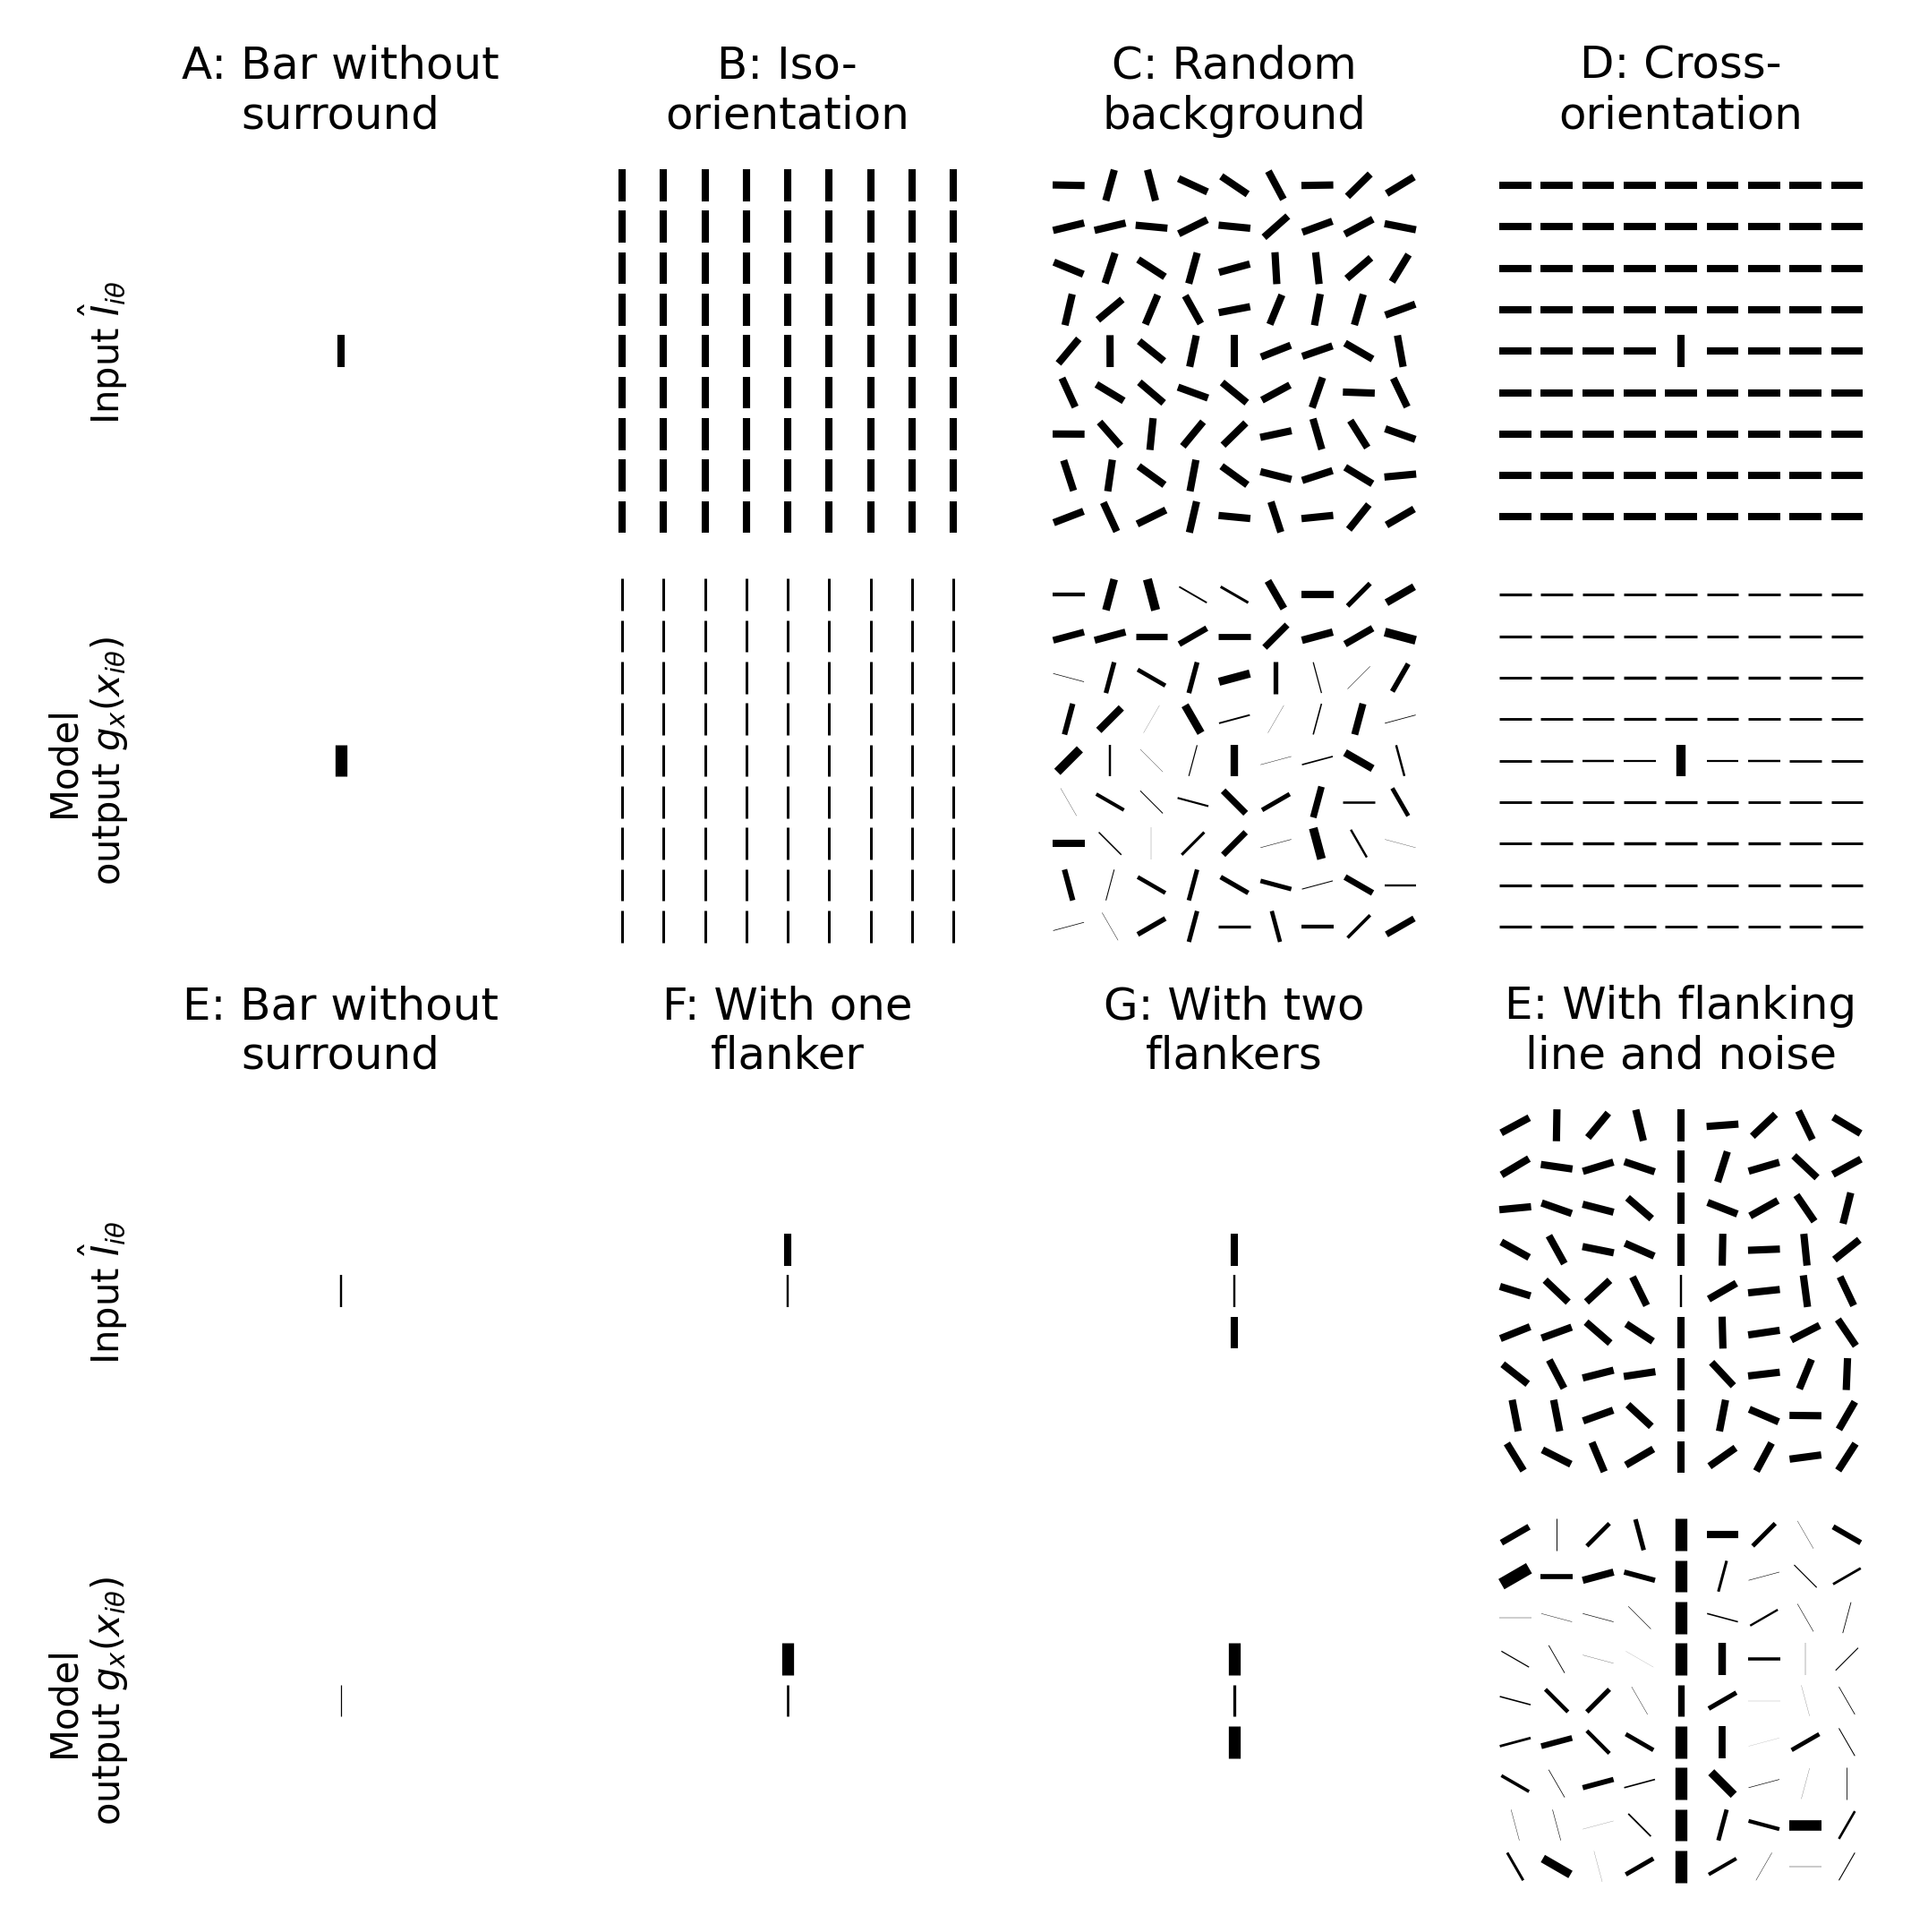

In [5]:
output_to_input_bar_width_ratio = 2.

# compute image size
dpi = 500
N_y, N_x = 9, 9
l = 9
r = 1.3
d = l * r  # grid spacing
img_height = int(N_y * d)
img_width = int(N_x * d)

# set up figure
plt.rcParams.update({"font.size": 6})
fig, axes = plt.subplots(
    4,
    4,
    figsize=(img_width / 100 * 4, img_height / 100 * 4),
    dpi=dpi,
    constrained_layout=True,
)

for index, (title, (A_in, C_in, A_out, C_out)) in enumerate(input_and_outputs.items()):
    x_index = index % 4
    y_setoff = index // 4
    
    # crop images to 9 x 9 central region
    N_y_test, N_x_test = A_in.shape
    y_mid, x_mid = int((N_y_test - 1) / 2), int((N_x_test - 1) / 2) # assert odd dimensions
    delta = int((N_y - 1) / 2) # assert odd dimensions
    A_in = A_in[y_mid - delta : y_mid + delta + 1, x_mid - delta : x_mid + delta + 1]
    C_in = C_in[y_mid - delta : y_mid + delta + 1, x_mid - delta : x_mid + delta + 1]
    A_out = A_out[y_mid - delta : y_mid + delta + 1, x_mid - delta : x_mid + delta + 1]
    C_out = C_out[y_mid - delta : y_mid + delta + 1, x_mid - delta : x_mid + delta + 1]
    
    # plot input
    top_axis = axes[y_setoff * 2, x_index]
    top_axis.set_title(title)
    visualize_input(A_in, C_in, verbose=False, axis=top_axis, dpi=dpi)
    if x_index == 0:
        # show axis again
        top_axis.axis("on")
        # hide all elements of axis except y label
        for spine in top_axis.spines.values():
            spine.set_visible(False)
        top_axis.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
        top_axis.set_xlabel('')
        # set y label
        top_axis.set_ylabel(r"Input $\hat{I}_{i\theta}$")
    
    # plot output
    bottom_axis = axes[2 * y_setoff + 1, x_index]
    visualize_output(A_out, output_to_input_bar_width_ratio * C_out, verbose=False, axis=bottom_axis, dpi=dpi)
    print(C_out[4, 4])
    if x_index == 0:        
        # show axis again
        bottom_axis.axis("on")
        # hide all elements of axis except y label
        for spine in bottom_axis.spines.values():
            spine.set_visible(False)
        bottom_axis.tick_params(axis='both', which='both', length=0, labelbottom=False, labelleft=False)
        bottom_axis.set_xlabel('')
        # set y label
        bottom_axis.set_ylabel("Model\noutput " + r"$g_x(x_{i\theta})$")

plt.show()

- colinear facilitation increases for higher bar contrast more, püossibyl because of different random background and thus orientation-independent normalization
- random background supresses bar less, mabe because of specific random background used her (slighly colinear activated possibly)